## Analyzing Bumble Profiles and User Behaviour

##### Bumble is a popular dating platform where users connect based on mutual interests and compatibility. To provide a better matchmaking experience, Bumble collects user information through profiles, which include details about demographics, lifestyle habits, and personal preferences. This dataset represents user-generated profiles, offering a rich source of information to understand user behavior, preferences, and trends.

#### Goal
##### Analyzing the Bumble dataset to answer key business and user behavior questions.

#### 1. Clean the Data:
##### Identify and handle missing values, duplicates, and incorrect data types.
##### Address outliers in numerical columns like age, height, and income.

#### 2. Process the Data:
##### Create new features, such as the number of days since a user was last online.
##### Standardize and scale numerical columns for better comparison.
##### Group ages into categories to better understand user demographics.

#### 3. Explore the Data:
##### Investigate the distribution of users by demographics, such as gender, location, and preferences.
##### Analyze relationships between lifestyle habits (e.g., diet, smoking, drinking).
##### Explore correlations between variables like age, income, and profile essay lengths.

#### 4. Visualize the Data:
##### Create charts and graphs to communicate your findings effectively.
##### Use bar charts, scatterplots, histograms, and heatmaps to uncover trends.



#### Dataset [Download](https://drive.google.com/file/d/1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o/view)

#### 1. Demographics
##### age: Age of the user.
##### status: Relationship status (e.g., single, married, seeing someone).
##### gender: Gender of the user (e.g., m, f).

#### 2. Physical Attributes
##### body_type: Descriptions of physical appearance (e.g., athletic, curvy, thin).
##### height: Height of the user (in inches).

#### 3. Lifestyle Preferences
##### diet: Dietary preferences (e.g., vegetarian, vegan, anything).
##### drinks: Drinking habits (e.g., socially, often).

#### 4. Educational and Financial Details
##### education: Education level (e.g., college, masters).
##### income: User-reported annual income.

#### 5. Location and Activity
##### location: City and state where the user resides.
##### last_online: Date and time when the user was last active.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv('bumble.csv')

In [3]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000,student,2012-06-28-14-22,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,-1,sales / marketing / biz dev,2012-06-12-21-47,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,-1,entertainment / media,2012-06-29-11-01,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently)
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000,construction / craftsmanship,2012-06-27-23-37,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently)
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,-1,medicine / health,2012-06-23-13-01,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ..."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB


### Part 1: Data Cleaning
#### 1. Inspecting Missing Data
##### Missing data is a common issue in real-world datasets. On a platform like Bumble, missing user information might reflect gaps in the user profile setup process, incomplete data collection, or users intentionally leaving certain fields blank. As a data analyst, your role is to assess the extent of missing data, understand its potential impact, and decide the most appropriate methods to address it.

#### Questions:
##### Which columns in the dataset have missing values, and what percentage of data is missing in each column?

##### Are there columns where more than 50% of the data is missing? Would you drop those columns where missing values are >50%. If yes, why?

##### How would you handle the missing numerical data (e.g., height, income)? Would you impute the missing data by the median or average value of height and income for the corresponding category, such as gender, age group, or location. If yes, why?



In [5]:
df.isnull().sum()

age                0
status             0
gender             0
body_type       5296
diet           24395
drinks          2985
education       6628
ethnicity       5680
height             3
income             0
job             8198
last_online        0
location           0
pets           19921
religion       20226
sign           11056
speaks            50
dtype: int64

In [6]:
missing_values = round(df.isnull().mean()*100,2)

In [7]:
missing_values

age             0.00
status          0.00
gender          0.00
body_type       8.83
diet           40.69
drinks          4.98
education      11.06
ethnicity       9.48
height          0.01
income          0.00
job            13.68
last_online     0.00
location        0.00
pets           33.23
religion       33.74
sign           18.44
speaks          0.08
dtype: float64

##### - The missing value analysis shows that the **diet** column contains **40.69% missing values**, indicating that a significant proportion of users did not disclose their dietary preferences. Since dietary preference is an optional profile attribute, this level of missingness is expected and does not necessarily indicate poor data quality.

In [8]:
df.describe()

,age,height,income
count,59946.000000,59943.000000,59946.000000
mean,32.340290,68.295281,20033.222534
std,9.452779,3.994803,97346.192104
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


In [9]:
missing_values['age']

0.0

In [10]:
missing_values['height']

0.01

In [11]:
missing_values['income']

0.0

In [12]:
missing_height = df[df['height'].isnull()]

In [13]:
missing_height 

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
36428,32,single,f,NaN,NaN,NaN,NaN,other,NaN,-1,artistic / musical / writer,2012-06-30-20-41,"berkeley, california",NaN,NaN,NaN,"english (fluently), german (fluently)"
54002,25,single,m,NaN,NaN,NaN,NaN,hispanic / latin,NaN,-1,NaN,2012-06-30-18-41,"guadalajara, mexico",NaN,NaN,aries,english
58983,49,single,m,NaN,NaN,NaN,NaN,NaN,NaN,-1,NaN,2012-07-01-08-35,"berkeley, california",likes cats,NaN,NaN,english (fluently)


##### - Missing values in the **age** column: **0**
##### - Missing values in the **income** column: **0** (no `NaN` values, but contains invalid `-1` entries)
##### - Missing values in the **height** column: **3**

##### - The three records with missing height values are largely incomplete, with most other profile information also missing.

##### - The `income` column contains `-1` values, which represent missing or invalid data rather than actual income. These values should be replaced with `NaN` before further analysis.

In [14]:
error_income = df[df['income'] < 0]

In [15]:
error_income

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english
5,29,single,m,average,mostly anything,socially,graduated from college/university,white,67.0,-1,computer / hardware / software,2012-06-29-19-18,"san francisco, california",likes cats,atheism,taurus,"english (fluently), chinese (okay)"
6,32,single,f,fit,strictly anything,socially,graduated from college/university,"white, other",65.0,-1,NaN,2012-06-25-20-45,"san francisco, california",likes dogs and likes cats,NaN,virgo,english
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59940,31,single,f,NaN,NaN,socially,working on masters program,middle eastern,62.0,-1,NaN,2012-07-01-00-40,"san francisco, california",likes dogs,agnosticism,sagittarius,"english (fluently), french, farsi"
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,-1,sales / marketing / biz dev,2012-06-12-21-47,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,-1,entertainment / media,2012-06-29-11-01,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently)
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,-1,medicine / health,2012-06-23-13-01,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ..."


In [16]:
df.loc[df.income == -1, 'income'] = np.nan

In [17]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28-14-22,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,sales / marketing / biz dev,2012-06-12-21-47,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,entertainment / media,2012-06-29-11-01,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently)
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,construction / craftsmanship,2012-06-27-23-37,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently)
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,medicine / health,2012-06-23-13-01,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ..."


##### - Replace all **`-1` values in the income column with `NaN`**, as they represent missing or undisclosed income rather than actual earnings. This prevents these values from skewing statistical calculations such as the mean, median, and correlation.

#### 2. Data Types
##### Accurate data types are critical for meaningful analysis and visualization. For example, numeric fields like income or height must be stored as numbers for statistical computations, while dates like last_online must be converted to datetime format for time-based calculations.

#### Questions:
##### Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?

##### Which columns require conversion to numerical data types for proper analysis (e.g., income)?

##### Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?



In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       11504 non-null  float64
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(2), int64(1), object(14)
memory usage: 7.8+ MB


##### The dataset was inspected for data type inconsistencies. Most columns had appropriate data types, while the **last_online** column was stored as an object (string) and required conversion to a datetime format for further analysis.

In [19]:
df['last_online'].dtype

dtype('O')

In [20]:
df['last_online'] = pd.to_datetime(df['last_online'], format='%Y-%m-%d-%H-%M', errors='coerce')


In [21]:
df['last_online']

0       2012-06-28 20:30:00
1       2012-06-29 21:41:00
2       2012-06-27 09:10:00
3       2012-06-28 14:22:00
4       2012-06-27 21:26:00
                ...        
59941   2012-06-12 21:47:00
59942   2012-06-29 11:01:00
59943   2012-06-27 23:37:00
59944   2012-06-23 13:01:00
59945   2012-06-29 00:42:00
Name: last_online, Length: 59946, dtype: datetime64[ns]

##### The `last_online` column was converted from a string to a datetime format. This allows date and time operations such as extracting the login date, login time, day, month, and analyzing user activity patterns.

In [22]:
df['last_online_date'] = df['last_online'].dt.date
df['last_online_date'] = pd.to_datetime(df['last_online_date'])

In [23]:
df['last_online_time'] = pd.to_datetime(df['last_online'], format='%H:%M:%S').dt.time

##### The datetime column was split into separate **date** and **time** fields to simplify analysis.

##### - **last_online_date** helps analyze user activity across different dates.
##### - **last_online_time** helps identify the most active hours of the day.

In [24]:
df.head()

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks,last_online_date,last_online_time
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,NaN,2012-06-27 09:10:00,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   age               59946 non-null  int64         
 1   status            59946 non-null  object        
 2   gender            59946 non-null  object        
 3   body_type         54650 non-null  object        
 4   diet              35551 non-null  object        
 5   drinks            56961 non-null  object        
 6   education         53318 non-null  object        
 7   ethnicity         54266 non-null  object        
 8   height            59943 non-null  float64       
 9   income            11504 non-null  float64       
 10  job               51748 non-null  object        
 11  last_online       59946 non-null  datetime64[ns]
 12  location          59946 non-null  object        
 13  pets              40025 non-null  object        
 14  religion          3972

##### - Convert all date-related columns to the datetime data type before analysis.
##### - Extract separate date and time fields whenever both daily and hourly activity patterns need to be analyzed.
##### - Ensure numerical columns remain in numeric format to support statistical analysis and visualizations.

#### 3. Outliers
##### Outliers are extreme values in the dataset that can distort averages, correlations, and overall trends. In the context of Bumble, an outlier in age (e.g., 110 years old) or income (e.g., $1,000,000 or -1) could represent errors or rare, invalid cases.

#### Questions:
##### Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?

##### Any -1 values in numerical columns like income should be replaced with blank, as they may represent missing or invalid data.

##### For other outliers, how would you ensure that they o not disproportionately impact the analysis while retaining as much meaningful data as possible. Would you delete the data or rather than deleting them, calculate the mean and median values using only the middle 80% of the data (removing extreme high and low values). Provide appropriate reasons for every step.

In [26]:
df.describe()

,age,height,income,last_online,last_online_date
count,59946.000000,59943.000000,11504.000000,59946,59946
mean,32.340290,68.295281,104394.993046,2012-05-22 06:43:35.300770560,2012-05-21 16:19:05.831248384
min,18.000000,1.000000,20000.000000,2011-06-27 01:52:00,2011-06-27 00:00:00
25%,26.000000,66.000000,20000.000000,2012-05-29 20:37:15,2012-05-29 00:00:00
50%,30.000000,68.000000,50000.000000,2012-06-27 14:30:00,2012-06-27 00:00:00
75%,37.000000,71.000000,100000.000000,2012-06-30 01:09:00,2012-06-30 00:00:00
max,110.000000,95.000000,1000000.000000,2012-07-01 08:57:00,2012-07-01 00:00:00
std,9.452779,3.994803,201433.528307,NaN,NaN


#### Outlier Analysis – Age

##### Outliers are unusually high or low values that can distort statistical analysis and visualizations. The age column was examined to identify extreme values and determine whether they represent valid observations or data quality issues.

##### The Z-score method was used to identify potential outliers in the age column. Additionally, the mean and median were compared to understand whether the distribution is significantly affected by extreme values.

In [27]:
mean = df['age'].mean()
std = df['age'].std()

z_scores = np.abs((df['age'] - mean) / std)

outliers_age = df['age'][z_scores > 3]
outliers_age

172      62
233      66
257      63
320      63
323      62
         ..
59428    68
59501    62
59601    69
59740    61
59837    66
Name: age, Length: 966, dtype: int64

(array([2.1863e+04, 2.2795e+04, 9.2200e+03, 3.6970e+03, 1.8860e+03,
        4.8300e+02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([ 18. ,  27.2,  36.4,  45.6,  54.8,  64. ,  73.2,  82.4,  91.6,
        100.8, 110. ]),
 <BarContainer object of 10 artists>)

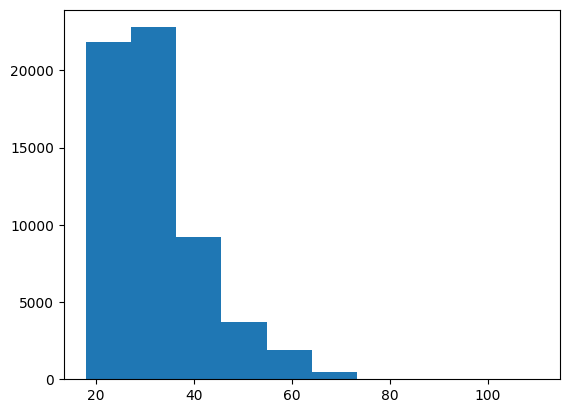

In [28]:
plt.hist(df['age'])

<Axes: ylabel='age'>

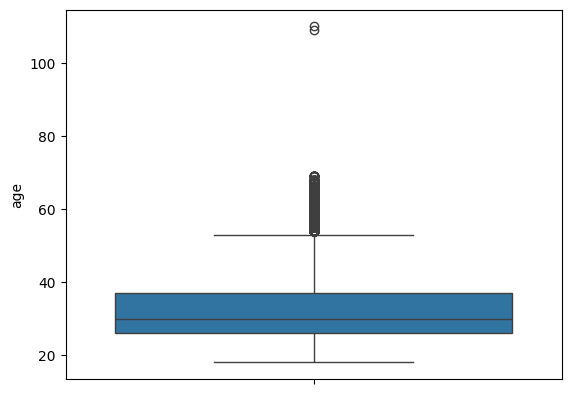

In [29]:
sns.boxplot(df['age'])

##### The Z-score helps identify observations that lie far from the average. Comparing the mean and median indicates whether outliers are skewing the distribution. Since the mean and median are nearly equal, the age distribution is approximately symmetric with only a few extreme values.


##### - Approximately **1.6%** of the records were identified as age outliers.
##### - The mean and median are nearly equal, indicating that extreme values have minimal impact on the overall distribution.
##### - Ages below **18 years** fall outside the expected user eligibility criteria for Bumble and are therefore considered invalid.

In [30]:
mean = df['age'].mean()
std = df['age'].std()
lower_fence = mean - 3*std
upper_fence = mean + 3*std

df = df[(df['age'] >= 18 ) & (df['age'] < upper_fence)]
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks,last_online_date,last_online_time
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,NaN,2012-06-27 09:10:00,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,sales / marketing / biz dev,2012-06-12 21:47:00,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,entertainment / media,2012-06-29 11:01:00,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,construction / craftsmanship,2012-06-27 23:37:00,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,medicine / health,2012-06-23 13:01:00,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00


#### Outlier Analysis – Height

##### The height column was analyzed to identify extreme values that could affect statistical summaries and visualizations. Detecting and handling these outliers helps improve the reliability of the analysis while preserving meaningful data.

##### The Z-score method was applied to the height column to identify observations that deviate significantly from the average. The mean and median were also compared to assess the impact of extreme values.

In [31]:
mean = df['height'].mean()
std = df['height'].std()

z_scores = np.abs((df['height'] - mean) / std)

outliers_height = df['height'][z_scores > 3]
outliers_height

402      91.0
546      83.0
1922     83.0
2020     56.0
2569     95.0
         ... 
57606    36.0
57915    83.0
57978    95.0
58147    94.0
58286    84.0
Name: height, Length: 129, dtype: float64

(array([6.0000e+00, 0.0000e+00, 1.0000e+00, 1.3000e+01, 4.0000e+00,
        4.6000e+01, 1.9153e+04, 3.9191e+04, 5.3100e+02, 3.2000e+01]),
 array([ 1. , 10.4, 19.8, 29.2, 38.6, 48. , 57.4, 66.8, 76.2, 85.6, 95. ]),
 <BarContainer object of 10 artists>)

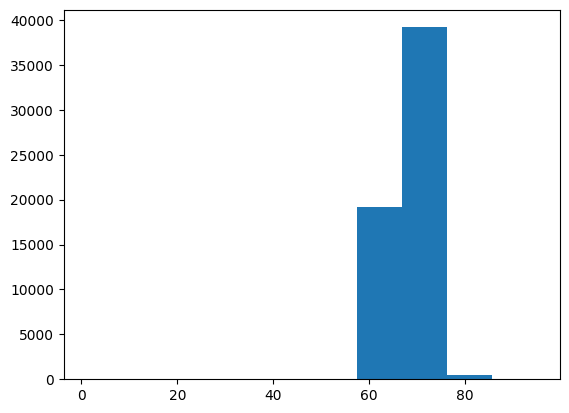

In [32]:
plt.hist(df['height'])

<Axes: ylabel='height'>

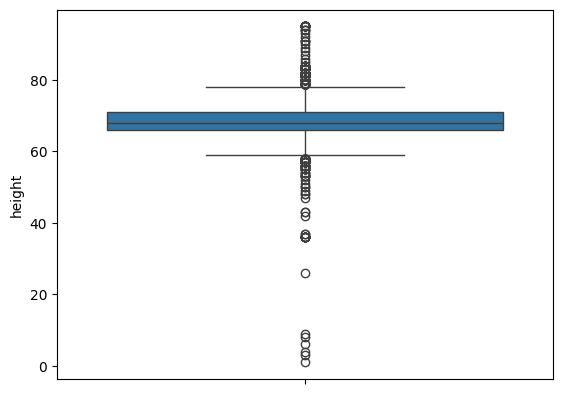

In [33]:
sns.boxplot(df['height'])

##### Using the Z-score helps identify unusually short or tall height values that may result from data entry errors or rare observations. Comparing the mean and median confirms whether these outliers significantly affect the overall distribution.

##### - Only **0.2%** of the records were identified as height outliers.
##### - The mean and median are very close, indicating that the height distribution is approximately symmetric.
##### - Since the proportion of outliers is extremely small, removing them has a negligible impact on the overall dataset while improving data quality.

In [34]:
mean = df['height'].mean()
std = df['height'].std()

lower_fence = mean - 3*std
upper_fence = mean + 3*std

df = df[(df['height'] > lower_fence ) & (df['height'] < upper_fence)]
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks,last_online_date,last_online_time
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,NaN,2012-06-27 09:10:00,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,sales / marketing / biz dev,2012-06-12 21:47:00,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,entertainment / media,2012-06-29 11:01:00,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,construction / craftsmanship,2012-06-27 23:37:00,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,medicine / health,2012-06-23 13:01:00,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58848 entries, 0 to 59945
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   age               58848 non-null  int64         
 1   status            58848 non-null  object        
 2   gender            58848 non-null  object        
 3   body_type         53616 non-null  object        
 4   diet              34919 non-null  object        
 5   drinks            55914 non-null  object        
 6   education         52343 non-null  object        
 7   ethnicity         53252 non-null  object        
 8   height            58848 non-null  float64       
 9   income            11260 non-null  float64       
 10  job               50772 non-null  object        
 11  last_online       58848 non-null  datetime64[ns]
 12  location          58848 non-null  object        
 13  pets              39255 non-null  object        
 14  religion          38840 non

#### Outlier Analysis – Income

##### The income column was analyzed to identify extreme values that could disproportionately influence statistical measures. Since income data is typically right-skewed, the Interquartile Range (IQR) method was used to detect outliers.

##### The IQR method was applied to the non-null income values after replacing invalid `-1` entries with `NaN`. This approach is more robust than the Z-score for skewed distributions and helps identify unusually high or low income values.

In [36]:
 df['income'].sort_values()

Q1,Q3 = np.nanpercentile(df['income'],[25,75])
print(Q1,Q3)

IQR = Q3-Q1
print(IQR)


20000.0 100000.0
80000.0


In [37]:
lower_fence = Q1 - 1.5*(IQR)
upper_fence = Q3 + 1.5*(IQR)
print(lower_fence, upper_fence)

-100000.0 220000.0


In [38]:

outliers = []

for i in df['income']:
    if (i < lower_fence) or (i > upper_fence):
        outliers.append(i)

print(outliers)

len(outliers)

[1000000.0, 1000000.0, 500000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 250000.0, 250000.0, 500000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 250000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 250000.0, 1000000.0, 250000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 250000.0, 500000.0, 250000.0, 250000.0, 1000000.0, 1000000.0, 1000000.0, 1000000.0, 500000.0, 500000.0, 100000

700

In [39]:
df['income'].info()

<class 'pandas.core.series.Series'>
Index: 58848 entries, 0 to 59945
Series name: income
Non-Null Count  Dtype  
--------------  -----  
11260 non-null  float64
dtypes: float64(1)
memory usage: 919.5 KB


##### Income data is often highly skewed, making the IQR method more appropriate than the Z-score. The IQR identifies observations that fall well outside the typical income range without being overly influenced by extreme values.

##### - The income distribution is positively skewed; therefore, the **IQR method** was used for outlier detection.
##### - Approximately **6.2%** of the non-null income records were identified as outliers.
##### - These extreme values can significantly affect measures such as the mean, correlation, and visualizations if left untreated.

In [40]:
df = df[
    ((df['income'] > lower_fence) & (df['income'] < upper_fence))
    | (df['income'].isna())
]

In [41]:
df_clean = df
df_clean

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks,last_online_date,last_online_time
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,transportation,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,hospitality / travel,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,NaN,2012-06-27 09:10:00,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,student,2012-06-28 14:22:00,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,artistic / musical / writer,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,sales / marketing / biz dev,2012-06-12 21:47:00,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,entertainment / media,2012-06-29 11:01:00,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,construction / craftsmanship,2012-06-27 23:37:00,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,medicine / health,2012-06-23 13:01:00,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00


### Part 2: Data Processing
#### 1. Binning and Grouping
##### Grouping continuous variables, such as age or income, into bins helps simplify analysis and identify trends among specific groups. For instance, grouping users into age ranges can reveal distinct patterns in behavior or preferences across demographics.

#### Questions:
##### How would you bin the age column into categories (e.g. "18-25", "26-35", "36-45", and "46+" ) to create a new column, age_group. How does the distribution of users vary across these age ranges?

##### Group income into categories like "Low Income," "Medium Income," and "High Income" based on meaningful thresholds (e.g., quartiles). What insights can be derived from these groups?

In [42]:
df_clean.describe()

,age,height,income,last_online,last_online_date
count,58148.000000,58148.000000,10560.000000,58148,58148
mean,31.838945,68.288798,57194.128788,2012-05-22 10:56:08.240352,2012-05-21 20:32:04.688725504
min,18.000000,57.000000,20000.000000,2011-06-27 01:52:00,2011-06-27 00:00:00
25%,26.000000,66.000000,20000.000000,2012-05-30 07:19:15,2012-05-30 00:00:00
50%,30.000000,68.000000,50000.000000,2012-06-27 15:10:00,2012-06-27 00:00:00
75%,36.000000,71.000000,80000.000000,2012-06-30 01:15:00,2012-06-30 00:00:00
max,60.000000,80.000000,150000.000000,2012-07-01 08:57:00,2012-07-01 00:00:00
std,8.603599,3.829211,36410.808136,NaN,NaN


### 1. Binning and Grouping

#### Age Grouping

##### Continuous variables such as age are often grouped into categories to simplify analysis and improve interpretation. Creating age groups makes it easier to compare user demographics, identify behavioral patterns, and understand how different age segments use the Bumble platform.

#### Creating Age Groups

##### The `age` column was divided into four categories:

##### - **18–25**
##### - **26–35**
##### - **36–45**
##### - **46+**

##### A new column, **age_group**, was created using these ranges to support demographic analysis and visualizations.

In [43]:
import pandas as pd
bins = [17, 25, 35, 45, df['age'].max()]
labels = ["18-25", "26-35", "36-45", "46+"]
df['age_group']= pd.cut(df['age'], bins = bins, labels = labels,  include_lowest=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\3068294571.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_group']= pd.cut(df['age'], bins = bins, labels = labels,  include_lowest=True)


In [44]:
df[['age', 'age_group']]

,age,age_group
0,22,18-25
1,35,26-35
2,38,36-45
3,23,18-25
4,29,26-35
...,...,...
59941,59,46+
59942,24,18-25
59943,42,36-45
59944,27,26-35


In [45]:
df['age_group'].value_counts()

age_group
26-35    28244
18-25    14190
36-45    10669
46+       5045
Name: count, dtype: int64

##### - The **26–35** age group has the highest number of users, accounting for nearly half of the platform's user base.
##### - The **18–25** age group is the second largest, indicating strong engagement among younger adults.
##### - User count gradually declines with increasing age, with the **46+** group having the fewest users.
##### - Overall, Bumble's user base is primarily concentrated in the **18–35** age range, making young adults the platform's dominant demographic.

(array([14190.,     0.,     0., 28244.,     0.,     0., 10669.,     0.,
            0.,  5045.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

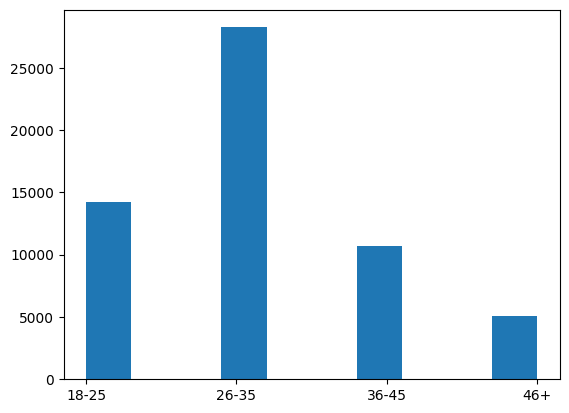

In [46]:
plt.hist(df["age_group"])

####  Income Grouping

##### Grouping income into categories simplifies analysis and helps compare users across different earning levels. Instead of analyzing individual income values, income groups provide a clearer understanding of the platform's economic distribution and support demographic comparisons.

#### Creating Income Groups

##### The `income` column was categorized using quartiles:

##### - **Low Income:** Below the 50th percentile
##### - **Medium Income:** Between the 50th and 75th percentile
##### - **High Income:** Above the 75th percentile

##### A new column, **income_group**, was created to facilitate income-based analysis.

In [47]:
df['income'].describe()

count     10560.000000
mean      57194.128788
std       36410.808136
min       20000.000000
25%       20000.000000
50%       50000.000000
75%       80000.000000
max      150000.000000
Name: income, dtype: float64

In [48]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
Q2 = df['income'].mean()
bins = [Q1-1, Q2, Q3, df['income'].max()]

labels = ["low income", "medium income", "high income"]

df['income_category'] = pd.cut(df['income'], bins = bins , labels=labels, include_lowest = True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\2107434381.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['income_category'] = pd.cut(df['income'], bins = bins , labels=labels, include_lowest = True)


In [49]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,last_online,location,pets,religion,sign,speaks,last_online_date,last_online_time,age_group,income_category
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,2012-06-28 20:30:00,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00,18-25,NaN
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,2012-06-29 21:41:00,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00,26-35,medium income
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,...,2012-06-27 09:10:00,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00,36-45,NaN
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,2012-06-28 14:22:00,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00,18-25,low income
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,...,2012-06-27 21:26:00,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00,26-35,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,...,2012-06-12 21:47:00,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00,46+,NaN
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,...,2012-06-29 11:01:00,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00,18-25,NaN
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,...,2012-06-27 23:37:00,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00,36-45,high income
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,...,2012-06-23 13:01:00,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00,26-35,NaN


In [50]:
df['income_category'].value_counts()

income_category
low income       5876
medium income    2486
high income      2198
Name: count, dtype: int64

##### - The **Low Income** category has the highest number of users (**5,876**), accounting for the majority of users with reported income.
##### - The **Medium Income** group consists of **2,486** users, while the **High Income** group has the fewest users (**2,198**).
##### - The distribution indicates that most Bumble users who reported their income fall into the **lower income segment**, with progressively fewer users in the higher income categories.
##### - This grouped income classification provides a useful basis for analyzing demographic and lifestyle trends across different earning levels.

#### 2. Unit Conversion
##### Standardizing units across datasets is essential for consistency, especially when working with numerical data. In the context of the Bumble dataset, users’ heights are given in inches, which may not be intuitive for all audiences.

#### Questions:
##### Convert the height column from inches to centimeters using the conversion factor (1 inch = 2.54 cm). Store the converted values in a new column, height_cm.


In [51]:
df['height'].dtype

dtype('float64')

In [52]:
df['height_cm']=df['height']*2.54

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\3721234324.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['height_cm']=df['height']*2.54


In [53]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,location,pets,religion,sign,speaks,last_online_date,last_online_time,age_group,income_category,height_cm
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00,18-25,NaN,190.50
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00,26-35,medium income,177.80
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,...,"san francisco, california",has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00,36-45,NaN,172.72
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00,18-25,low income,180.34
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,...,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00,26-35,NaN,167.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,...,"oakland, california",has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00,46+,NaN,157.48
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,...,"san francisco, california",likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00,18-25,NaN,182.88
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,...,"south san francisco, california",NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00,36-45,high income,180.34
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,...,"san francisco, california",likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00,26-35,NaN,185.42


#### 3. Derived Features
##### Derived features are new columns created based on the existing data to add depth to the analysis. These features often reveal hidden patterns or provide new dimensions to explore.

#### Questions:
##### Create a new feature, profile_completeness, by calculating the percentage of non-missing values for each user profile. How complete are most user profiles, and how does completeness vary across demographics?

In [54]:
df['profile_completeness'] = (1-round(df.isna().mean(axis=1),2))*100

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\4218782080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['profile_completeness'] = (1-round(df.isna().mean(axis=1),2))*100


##### A new feature, **profile_completeness**, was created by calculating the percentage of non-missing values in each user profile. This metric helps measure how complete users' profiles are and allows us to compare profile completeness across different demographic groups.

In [55]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,pets,religion,sign,speaks,last_online_date,last_online_time,age_group,income_category,height_cm,profile_completeness
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,likes dogs and likes cats,agnosticism and very serious about it,gemini,english,2012-06-28,20:30:00,18-25,NaN,190.50,91.0
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00,26-35,medium income,177.80,100.0
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,...,has cats,NaN,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00,36-45,NaN,172.72,77.0
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,likes cats,NaN,pisces,"english, german (poorly)",2012-06-28,14:22:00,18-25,low income,180.34,95.0
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,...,likes dogs and likes cats,NaN,aquarius,english,2012-06-27,21:26:00,26-35,NaN,167.64,82.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,...,has dogs,catholicism but not too serious about it,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00,46+,NaN,157.48,77.0
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,...,likes dogs and likes cats,agnosticism,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00,18-25,NaN,182.88,91.0
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,...,NaN,christianity but not too serious about it,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00,36-45,high income,180.34,95.0
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,...,likes dogs and likes cats,agnosticism but not too serious about it,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00,26-35,NaN,185.42,91.0


##### Profile completeness is an indicator of user engagement and data quality. More complete profiles provide richer information for analysis and can improve user matching and personalization on the platform.

In [56]:
df.groupby('age_group')['profile_completeness'].mean()

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\3513720016.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['profile_completeness'].mean()


age_group
18-25    84.385060
26-35    84.259028
36-45    84.937014
46+      85.580773
Name: profile_completeness, dtype: float64

In [57]:
df.groupby('gender')['profile_completeness'].mean()

gender
f    84.179466
m    84.764565
Name: profile_completeness, dtype: float64

In [58]:
df.groupby('status')['profile_completeness'].mean()

status
available         85.542524
married           85.243243
seeing someone    85.207221
single            84.466800
unknown           79.100000
Name: profile_completeness, dtype: float64

##### - Overall, user profiles are **highly complete**, with an average completeness of around **84–86%**.
##### - Profile completeness is fairly consistent across age groups, with users aged **46+ (85.58%)** having the most complete profiles.
##### - Male users (**84.76%**) have slightly more complete profiles than female users (**84.18%**).
##### - Among relationship statuses, **available** users have the highest profile completeness (**85.54%**), while users with **unknown** status have the lowest (**79.10%**), indicating less profile information.

### Part 3: Data Analysis
#### 1. Demographic Analysis
##### Understanding the demographics of users is essential for tailoring marketing strategies, improving user experience, and designing features that resonate with the platform’s audience. Insights into gender distribution, orientation, and relationship status can help Bumble refine its matchmaking algorithms and engagement campaigns.

#### Questions:
##### What is the gender distribution (gender) across the platform? Are there any significant imbalances?

##### What are the proportions of users in different status categories (e.g., single, married, seeing someone)? What does this suggest about the platform’s target audience?

##### How does status vary by gender? For example, what proportion of men and women identify as single?

##### Demographic analysis helps understand Bumble's user base by examining gender and relationship status. These insights can support better matchmaking, user segmentation, and targeted marketing strategies.

In [59]:
round(df['gender'].value_counts(normalize=True),2)*100

gender
m    60.0
f    40.0
Name: proportion, dtype: float64

##### - Male users account for **60%** of the platform, while female users account for **40%**.
##### - This indicates a moderate gender imbalance, with more male users than female users.

In [60]:
round(df['status'].value_counts(normalize=True),4)*100

status
single            92.90
seeing someone     3.48
available          3.09
married            0.51
unknown            0.02
Name: proportion, dtype: float64

##### - **Single** is the most common relationship status, showing that Bumble primarily attracts users looking for relationships.
##### - Only a small proportion of users reported being **available**, **seeing someone**, or **married**.

##### - **Single** is the most common relationship status, showing that Bumble primarily attracts users looking for relationships.
##### - Only a small proportion of users reported being **available**, **seeing someone**, or **married**.

In [61]:
df1 = df.query("gender == 'm'")
round(df1['status'].value_counts(normalize=True),4)*100

status
single            93.17
available          3.34
seeing someone     2.99
married            0.48
unknown            0.02
Name: proportion, dtype: float64

##### status against female

In [62]:
df2 = df.query("gender == 'f'")
round(df2['status'].value_counts(normalize=True),4)*100

status
single            92.50
seeing someone     4.20
available          2.73
married            0.56
unknown            0.02
Name: proportion, dtype: float64

In [63]:
 status_gender = round(pd.crosstab(df['gender'], df['status'], normalize='index'),4)*100

In [64]:
status_gender

status,available,married,seeing someone,single,unknown
gender,,,,,
f,2.73,0.56,4.20,92.50,0.02
m,3.34,0.48,2.99,93.17,0.02


##### - Around **93.17%** of male users and **92.50%** of female users identify as **single**.
##### - Female users are slightly more likely to report **seeing someone** (**4.20%**) than male users (**2.99%**).
##### - Male users have a slightly higher percentage of **available** status (**3.34%**) compared to females (**2.73%**).
##### - Overall, the relationship status distribution is very similar across both genders.

#### Recommendations

##### - Focus engagement and marketing efforts on **single users**, as they form the majority of the user base.
##### - Monitor gender balance and user demographics to improve matchmaking and user experience.

#### 2. Correlation Analysis
##### Correlation analysis helps uncover relationships between variables, guiding feature engineering and hypothesis generation. For example, understanding how age correlates with income or word count in profiles can reveal behavioral trends that inform platform design.

#### Questions:
##### What are the correlations between numerical columns such as age, income, gender Are there any strong positive or negative relationships?

##### How does age correlate with income? Are older users more likely to report higher income levels?



In [65]:
correlation = df[['income','age','height']].corr()
correlation 

,income,age,height
income,1.000000,0.376855,0.140772
age,0.376855,1.000000,-0.011900
height,0.140772,-0.011900,1.000000


##### - **Age and income** have a correlation coefficient of **0.38**, indicating a **weak to moderate positive relationship**. This suggests that income generally tends to increase with age.
##### - **Income and height** show a **very weak positive correlation (0.14)**, indicating little association between the two variables.
##### - **Age and height** have an almost **zero correlation (-0.01)**, suggesting no meaningful relationship.

In [66]:
corr_income_age = df[['income', 'age']].corr()
corr_income_age

,income,age
income,1.000000,0.376855
age,0.376855,1.000000


##### - The correlation coefficient between **age and income** is **0.38**, indicating a **weak to moderate positive relationship**.
##### - Older users generally tend to report higher incomes, but age alone is not a strong predictor of income.
##### - Other factors such as education, occupation, and experience are likely to have a greater influence on income levels.

#### Recommendations

##### - Consider additional variables such as education and location when analyzing income.
##### - Avoid interpreting correlation as causation, as multiple factors influence users' income.

#### 3. Diet and Lifestyle Analysis
##### Lifestyle attributes such as diet, drinks provide insights into user habits and preferences. Analyzing these factors helps identify compatibility trends and inform product features like filters or match recommendations.

#### Questions:
##### How do dietary preferences (diet) distribute across the platform? For example, what percentage of users identify as vegetarian, vegan, or follow "anything" diets?

##### How do drinking habits (drinks) vary across different diet categories? Are users with stricter diets (e.g., vegan) less likely to drink?

In [67]:
df['diet'].value_counts(normalize=True)*100

diet
mostly anything        46.777052
anything               17.466957
strictly anything      14.445897
mostly vegetarian       9.562818
mostly other            2.771242
strictly vegetarian     2.486565
vegetarian              1.899782
strictly other          1.211329
mostly vegan            0.932462
other                   0.917938
strictly vegan          0.647785
vegan                   0.386347
mostly kosher           0.229484
mostly halal            0.122004
strictly halal          0.046478
strictly kosher         0.037763
halal                   0.029049
kosher                  0.029049
Name: proportion, dtype: float64

##### - **Mostly anything (46.78%)** is the most common dietary preference, followed by **anything (17.47%)** and **strictly anything (14.45%)**.
##### - Vegetarian and vegan diets account for a much smaller share of users, indicating that most users do not follow strict dietary restrictions.
##### - Overall, the platform is dominated by users with flexible eating habits.

In [68]:
df['drinks'].value_counts(normalize=True)*100

drinks
socially       73.660585
rarely         10.371416
often           9.068202
not at all      5.596583
very often      0.785549
desperately     0.517666
Name: proportion, dtype: float64

##### - **Social drinking (73.66%)** is the most common drinking habit across the platform.
##### - This is followed by **rarely (10.37%)** and **often (9.07%)**.
##### - Very few users reported drinking **very often** or **desperately**.

In [69]:
diet_drinks = round(pd.crosstab(df['diet'], df['drinks'], normalize= 'index'),2)*100
diet_drinks

drinks,desperately,not at all,often,rarely,socially,very often
diet,,,,,,
anything,0.0,5.0,10.0,8.0,76.0,1.0
halal,0.0,38.0,12.0,0.0,50.0,0.0
kosher,0.0,10.0,0.0,20.0,60.0,10.0
mostly anything,0.0,5.0,9.0,9.0,76.0,1.0
mostly halal,5.0,23.0,3.0,21.0,41.0,8.0
mostly kosher,1.0,8.0,4.0,22.0,61.0,4.0
mostly other,1.0,9.0,5.0,18.0,66.0,1.0
mostly vegan,1.0,11.0,6.0,20.0,61.0,1.0
mostly vegetarian,1.0,6.0,7.0,14.0,72.0,1.0


##### - Across almost all diet categories, **social drinking** is the most common behavior.
##### - Users with **strict vegan** and **strict halal** diets have a relatively higher proportion of **not at all** drinking compared to users with flexible diets.
##### - Overall, stricter dietary preferences are generally associated with lower alcohol consumption, although social drinking remains common among most users.

#### Recommendations

##### - Use diet and drinking preferences as compatibility filters in the matching algorithm.
##### - Recommend matches with similar lifestyle habits to improve user compatibility and engagement.

#### 4. Geographical Insights
##### Analyzing geographical data helps Bumble understand its user base distribution, enabling targeted regional campaigns and feature localization. For instance, identifying the top cities with active users can guide marketing efforts in those areas.

#### Questions:
##### Extract city and state information from the location column. What are the top 5 cities and states with the highest number of users?

##### How does age vary across the top cities? Are certain cities dominated by younger or older users?

##### What are the average income levels in the top states or cities? Are there regional patterns in reported income

In [70]:
df[['city', 'state']] = df['location'].str.split(',', n=1, expand=True)

df['city'] = df['city'].str.strip()
df['state'] = df['state'].str.strip()

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\4277917084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['city', 'state']] = df['location'].str.split(',', n=1, expand=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\4277917084.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['city', 'state']] = df['location'].str.split(',', n=1, expand=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\4277917084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [71]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,sign,speaks,last_online_date,last_online_time,age_group,income_category,height_cm,profile_completeness,city,state
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,gemini,english,2012-06-28,20:30:00,18-25,NaN,190.50,91.0,south san francisco,california
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,cancer,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00,26-35,medium income,177.80,100.0,oakland,california
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,...,pisces but it doesn&rsquo;t matter,"english, french, c++",2012-06-27,09:10:00,36-45,NaN,172.72,77.0,san francisco,california
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,pisces,"english, german (poorly)",2012-06-28,14:22:00,18-25,low income,180.34,95.0,berkeley,california
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,...,aquarius,english,2012-06-27,21:26:00,26-35,NaN,167.64,82.0,san francisco,california
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,...,cancer and it&rsquo;s fun to think about,english,2012-06-12,21:47:00,46+,NaN,157.48,77.0,oakland,california
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,...,leo but it doesn&rsquo;t matter,english (fluently),2012-06-29,11:01:00,18-25,NaN,182.88,91.0,san francisco,california
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,...,sagittarius but it doesn&rsquo;t matter,english (fluently),2012-06-27,23:37:00,36-45,high income,180.34,95.0,south san francisco,california
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,...,leo and it&rsquo;s fun to think about,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00,26-35,NaN,185.42,91.0,san francisco,california


##### Geographical analysis helps identify where Bumble's users are concentrated and how user demographics vary across different regions. These insights can support localized marketing campaigns and region-specific product strategies.

In [72]:
top_city = df['city'].value_counts().head(5)
top_city

city
san francisco    30369
oakland           6979
berkeley          4048
san mateo         1284
palo alto         1034
Name: count, dtype: int64

In [73]:
top_city = df['city'].value_counts().head(5).index
top_city

Index(['san francisco', 'oakland', 'berkeley', 'san mateo', 'palo alto'], dtype='object', name='city')

In [74]:
df[df['city'].isin(top_city)].groupby('city')['income'].median()

city
berkeley         30000.0
oakland          40000.0
palo alto        70000.0
san francisco    60000.0
san mateo        65000.0
Name: income, dtype: float64

##### - **Palo Alto** has the highest median reported income (**70,000**), followed by **San Mateo (65,000)** and **San Francisco (60,000)**.
###### - **Oakland** has a median income of **40,000**, while **Berkeley** reports the lowest median income (**30,000**) among the top five cities.
##### - Overall, users in **Palo Alto**, **San Mateo**, and **San Francisco** tend to report higher incomes, reflecting regional differences in earning levels across cities.

In [75]:
top_state = df['state'].value_counts().head(5)
top_state

state
california       58059
new york            16
illinois             8
massachusetts        5
texas                4
Name: count, dtype: int64

In [76]:
top_state = df['state'].value_counts().head(5).index
top_state

Index(['california', 'new york', 'illinois', 'massachusetts', 'texas'], dtype='object', name='state')

In [77]:
df[df['state'].isin(top_state)].groupby('state')['income'].median()

state
california       50000.0
illinois             NaN
massachusetts    30000.0
new york         40000.0
texas            20000.0
Name: income, dtype: float64

##### - **California** reports the highest median income (**50,000**), followed by **New York (40,000)** and **Massachusetts (30,000)**.
##### - **Texas** has the lowest reported median income (**20,000**), while **Illinois** has no reported income values in the dataset.
##### - Overall, income levels vary across states, indicating regional differences in users' reported earnings.

##### - **San Francisco** has the largest user base (**30,369**), followed by **Oakland**, **Berkeley**, **San Mateo**, and **Palo Alto**.
##### - Most users are concentrated in **California**, indicating it is Bumble's primary market in this dataset.

In [78]:
top_cities = df['city'].value_counts().head(5).index
top_city_age_group = pd.crosstab(
    df.loc[df['city'].isin(top_cities), 'city'],
    df.loc[df['city'].isin(top_cities), 'age_group'],
    normalize='index'
) * 100

print(top_city_age_group)


age_group          18-25      26-35      36-45        46+
city                                                     
berkeley       34.387352  43.428854  13.364625   8.819170
oakland        19.845250  49.319387  21.894254   8.941109
palo alto      28.529981  47.001934  13.733075  10.735010
san francisco  22.285884  53.297771  18.637426   5.778919
san mateo      22.274143  46.573209  19.080997  12.071651


###### - The **26–35** age group is the largest across all top cities, accounting for nearly half of users in each city.
##### - **Berkeley** has the highest proportion of younger users (**18–25**), while **San Mateo** has the highest share of users aged **46+**.
##### - Overall, the top cities are dominated by young and middle-aged adults.

In [79]:
top_states = df['state'].value_counts().head(5).index
top_state_age_group = pd.crosstab(
    df.loc[df['state'].isin(top_states), 'state'],
    df.loc[df['state'].isin(top_states), 'age_group'],
    normalize='index'
) * 100

print(top_state_age_group)


age_group         18-25       26-35      36-45       46+
state                                                   
california     24.40104   48.557502  18.357188  8.684269
illinois       12.50000   75.000000  12.500000  0.000000
massachusetts  40.00000   20.000000  40.000000  0.000000
new york       25.00000   68.750000   6.250000  0.000000
texas           0.00000  100.000000   0.000000  0.000000


##### - **California** has a well-balanced user base, with the majority belonging to the **26–35** age group.
##### - The smaller states in the dataset (**Texas, New York, Illinois, and Massachusetts**) have limited observations but are also largely dominated by users aged **26–35**.

#### Recommendations

##### - Focus regional marketing efforts on **California**, particularly **San Francisco**, where user concentration is highest.
##### - Consider age-specific campaigns, as users aged **26–35** dominate most cities and states.
##### - Use regional income insights to personalize premium features and pricing strategies where appropriate.

#### 5. Height Analysis
##### Physical attributes like height are often considered important in dating preferences. Analyzing height patterns helps Bumble understand user demographics and preferences better.

#### Questions:
###### What is the average height of users across different gender categories?

##### How does height vary by age_group? Are there noticeable trends among younger vs. older users?

##### What is the distribution of height within body_type categories (e.g., athletic, curvy, thin)? Do the distributions align with expectations?



In [80]:
round(df.groupby('gender')['height_cm'].mean(),4)


gender
f    165.4020
m    178.8853
Name: height_cm, dtype: float64

##### - Male users have an average height of **178.89 cm**, while female users have an average height of **165.40 cm**.
##### - As expected, male users are taller on average than female users.

In [81]:
round(df.groupby('age_group')['height_cm'].mean(),4)

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\3082184428.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  round(df.groupby('age_group')['height_cm'].mean(),4)


age_group
18-25    173.1625
26-35    173.7011
36-45    173.5168
46+      172.7522
Name: height_cm, dtype: float64

##### - The average height remains fairly consistent across all age groups, ranging from **172.75 cm** to **173.70 cm**.
##### - Users aged **26–35** have the highest average height (**173.70 cm**), while the **46+** group has the lowest (**172.75 cm**).
##### - Overall, there is **no significant relationship** between age and height in the dataset.

In [82]:
df.groupby('body_type')['height_cm'].mean()

body_type
a little extra    174.795329
athletic          176.955617
average           173.011619
curvy             165.665921
fit               174.114587
full figured      168.754035
jacked            175.435638
overweight        174.709371
rather not say    170.365208
skinny            174.048190
thin              172.422383
used up           174.912508
Name: height_cm, dtype: float64


##### - Users with **athletic (176.96 cm)** and **jacked (175.44 cm)** body types have the highest average heights.
##### - **Curvy (165.67 cm)** and **full figured (168.75 cm)** users have the lowest average heights.
##### - Most body type categories have average heights between **172 cm and 175 cm**, indicating only moderate variation across body types.

#### Recommendations

##### - Use **gender-specific height distributions** when analyzing user demographics, as significant differences exist between male and female users.
##### - Height should not be used as a proxy for age since it remains relatively consistent across all age groups.
##### - Combine **height with body type and other profile attributes** to gain deeper insights into user characteristics and preferences.
##### - Since only minor variations exist across age groups and body types, height is best treated as a descriptive feature rather than a primary factor in user segmentation.

#### 6. Income Analysis

##### What is the distribution of income across the platform? Are there specific income brackets that dominate? How would you handle case where income is blank or 0?

##### How does income vary by age_group and gender? Are older users more likely to report higher incomes?

In [83]:
df['income'].describe()

count     10560.000000
mean      57194.128788
std       36410.808136
min       20000.000000
25%       20000.000000
50%       50000.000000
75%       80000.000000
max      150000.000000
Name: income, dtype: float64

In [84]:
df['income_category'].value_counts(normalize= True)*100 

income_category
low income       55.643939
medium income    23.541667
high income      20.814394
Name: proportion, dtype: float64

In [85]:
df.groupby('income_category')['income'].median()

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\3292502812.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('income_category')['income'].median()


income_category
low income        30000.0
medium income     70000.0
high income      100000.0
Name: income, dtype: float64

##### - The **median income is 50,000**, while the **average income is 57,194**, indicating a slightly right-skewed distribution.
##### - More than half of the users (**55.64%**) belong to the **Low Income** category, followed by **Medium Income (23.54%)** and **High Income (20.81%)**.
##### - Blank or invalid income values (such as `-1`) should be treated as missing values (`NaN`) and excluded from income-based analysis.

In [86]:
 df.groupby('age_group')['income'].median()

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\730504680.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['income'].median()


age_group
18-25    20000.0
26-35    50000.0
36-45    70000.0
46+      70000.0
Name: income, dtype: float64

##### - Median income increases with age, from **20,000** for users aged **18–25** to **70,000** for users aged **36–45** and **46+**.
##### - This indicates that older users generally report higher incomes, likely due to greater work experience and career progression.

In [87]:
 df.groupby('gender')['income'].median()

gender
f    40000.0
m    50000.0
Name: income, dtype: float64

##### - Male users report a higher median income (**50,000**) than female users (**40,000**).
##### - Although both genders span similar income ranges, the median suggests a modest difference in reported earnings.

#### Recommendations

##### - Treat blank or invalid income values as **missing (`NaN`)** before analysis.
##### - Use **age group** and **income category** together for user segmentation, as income generally increases with age.
##### - Leverage income segments to personalize premium features, recommendations, and targeted marketing campaigns.

### Part 4: Data Visualization
#### 1. Age Distribution
##### Understanding the distribution of user ages can reveal whether the platform caters to specific demographics or age groups. This insight is essential for targeted marketing and user experience design.

#### Questions:
##### Plot a histogram of age with a vertical line indicating the mean age. What does the distribution reveal about the most common age group on the platform?

##### How does the age distribution differ by gender? Are there age groups where one gender is more prevalent?



##### Visualizing the age distribution helps identify the primary age groups using the Bumble platform. This insight enables better user segmentation, targeted marketing, and product development tailored to the platform's core audience.

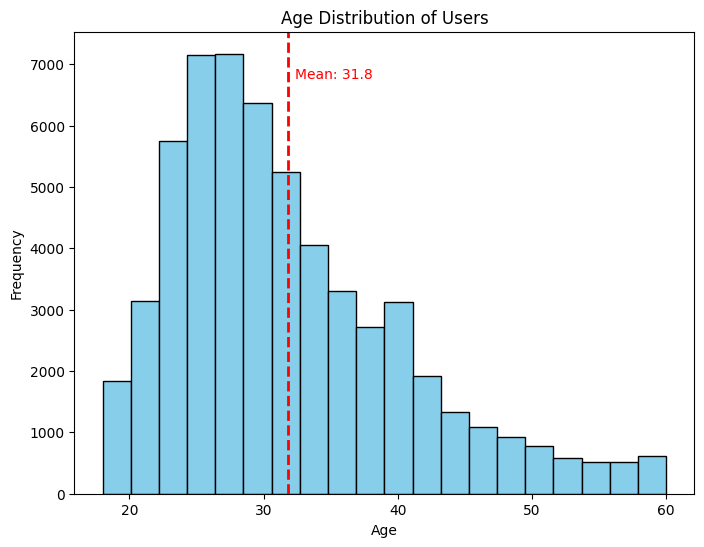

In [88]:
plt.figure(figsize=(8,6))
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')

mean_age = df['age'].mean()
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2)

plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.text(mean_age+0.5, plt.ylim()[1]*0.9, f'Mean: {mean_age:.1f}', color='red')

plt.show()


##### - The age distribution is **right-skewed**, with most users concentrated between **25 and 35 years**.
##### - The **mean age is approximately 31.8 years**, indicating that the average Bumble user is in their early thirties.
##### - The number of users gradually decreases after the mid-30s, with relatively fewer users above **45 years**.
##### - Overall, the platform primarily attracts **young adults**, particularly those in the **26–35** age group.

In [89]:
age_gender_dist = pd.crosstab(df['age_group'], df['gender'], normalize='index') * 100
print(age_gender_dist)


gender             f          m
age_group                      
18-25      41.035941  58.964059
26-35      38.645376  61.354624
36-45      41.109757  58.890243
46+        45.609514  54.390486


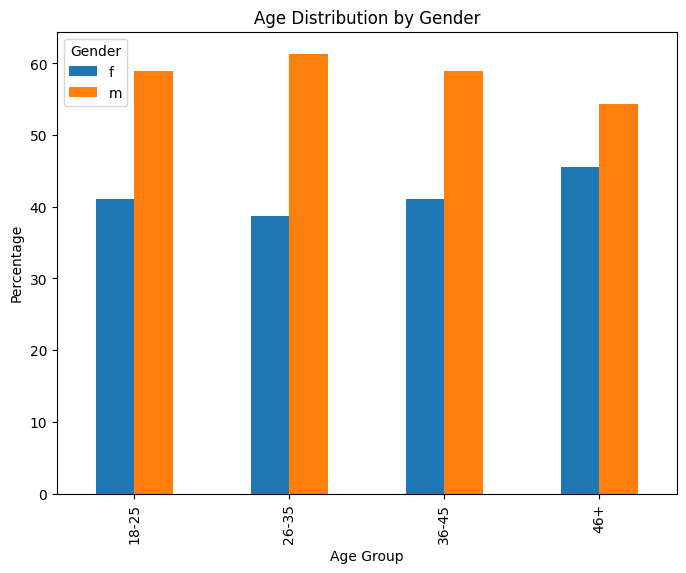

In [90]:
age_gender_dist.plot(kind='bar', figsize=(8,6))
plt.title('Age Distribution by Gender')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.legend(title='Gender')
plt.show()


##### - Across all age groups, **male users outnumber female users**.
##### - The **26–35** age group has the highest representation for both genders, making it the platform's largest demographic segment.
##### - The gender gap is largest in the **26–35** age group and narrows slightly among users aged **46+**.
##### - Overall, the distribution suggests that Bumble is predominantly used by **young and middle-aged adults**, with a higher proportion of male users across every age group.

#### 2. Income and Age
##### Visualizing the relationship between income and age helps uncover patterns in reported income levels across age groups, which could inform user segmentation strategies.

#### Questions:
##### Use a scatterplot to visualize the relationship between income and age, with a trend line indicating overall patterns. Are older users more likely to report higher incomes?

##### Create boxplots of income grouped by age_group. Which age group reports the highest median income?

##### Analyze income levels within gender and status categories. For example, are single men more likely to report higher incomes than single women?

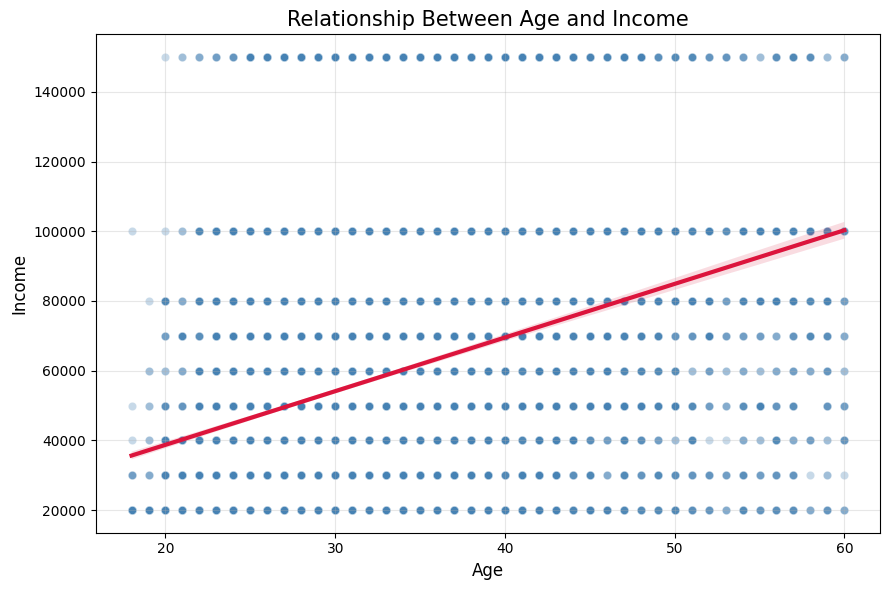

In [91]:
plt.figure(figsize=(9,6))

sns.scatterplot(x='age', y='income', data=df, alpha=0.3, s=35, color='steelblue')

sns.regplot(x='age', y='income', data=df, scatter=False, color='crimson',
            line_kws={'linewidth':3})

plt.title("Relationship Between Age and Income", fontsize=15)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Income", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

##### - The scatter plot shows a **positive relationship** between age and income, with the trend line increasing as age increases.
##### - Although income generally rises with age, there is considerable variation in income within each age group.
##### - This observation is consistent with the correlation coefficient (**0.38**), indicating a **weak to moderate positive relationship** between age and income.
##### - Overall, older users tend to report higher incomes, but age alone is not a strong predictor of income.

#### Recommendations

##### - Use **age and income together** for user segmentation rather than relying on either variable independently.
##### - Consider additional factors such as education, occupation, and location to better understand differences in income.
##### - Leverage these insights to personalize recommendations and premium offerings for different user segments.

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\4029811088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='income', data=df, palette='Set2')


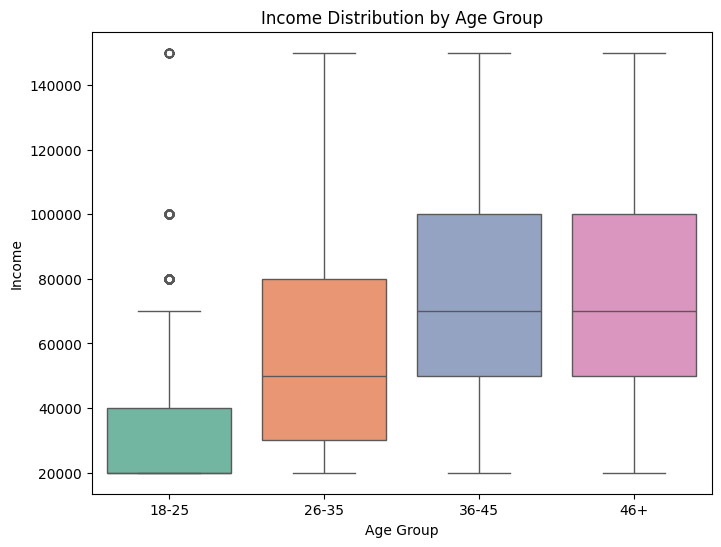

In [92]:

plt.figure(figsize=(8,6))
sns.boxplot(x='age_group', y='income', data=df, palette='Set2')

plt.title('Income Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Income')
plt.show()


##### - The **18–25** age group has the **lowest median income** (**20,000**) and the narrowest income distribution.
##### - Median income increases for the **26–35** age group (**50,000**) and reaches its highest level in the **36–45** and **46+** age groups (**70,000**).
##### - Older age groups show a wider spread of income, indicating greater variation in earnings.
##### - Overall, the boxplot confirms that **income generally increases with age**, consistent with the positive correlation observed earlier.

#### Recommendations

##### - Use **age groups** for income-based user segmentation, as earnings generally increase with age.
##### - Target premium features and subscription plans toward older age groups, which tend to report higher incomes.
##### - Consider additional factors such as education and occupation to better explain the variation in income within each age group.

In [93]:
income_gender_status = df.groupby(['gender', 'status'])['income'].median().unstack()
print(income_gender_status)


status  available  married  seeing someone   single  unknown
gender                                                      
f         20000.0  30000.0         20000.0  40000.0  20000.0
m         50000.0  60000.0         40000.0  50000.0      NaN


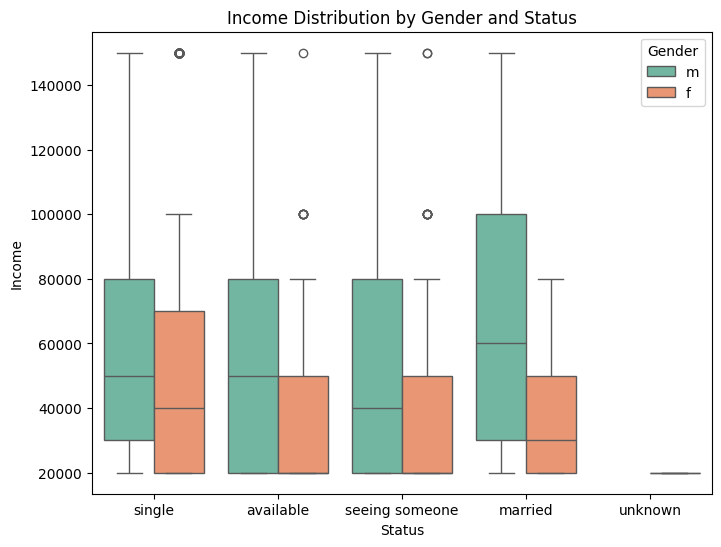

In [94]:

plt.figure(figsize=(8,6))
sns.boxplot(x='status', y='income', hue='gender', data=df, palette='Set2')

plt.title('Income Distribution by Gender and Status')
plt.xlabel('Status')
plt.ylabel('Income')
plt.legend(title='Gender')
plt.show()


##### - Across almost all relationship statuses, **male users report higher median incomes** than female users.
##### - **Single men** have a higher median income than **single women**, and a similar pattern is observed for **available**, **seeing someone**, and **married** users.
##### - The **married male** group shows the highest median income among all gender–status combinations.
##### - Income variability is also greater among male users, indicating a wider range of reported earnings.

#### Recommendations

##### - Consider both **gender and relationship status** when analyzing income patterns, as both influence reported earnings.
##### - Use these demographic insights to personalize recommendations and premium offerings for different user segments.
##### - Investigate additional factors such as education, occupation, and location to better understand income differences between genders.

#### 3. Pets and Preferences
##### Pets are often a key lifestyle preference and compatibility factor. Analyzing how pets preferences distribute across demographics can provide insights for filters or recommendations.

#### Questions:
##### Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?

##### How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?

##### Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?

##### How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\2743401632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pets', data=df, palette='Set3',


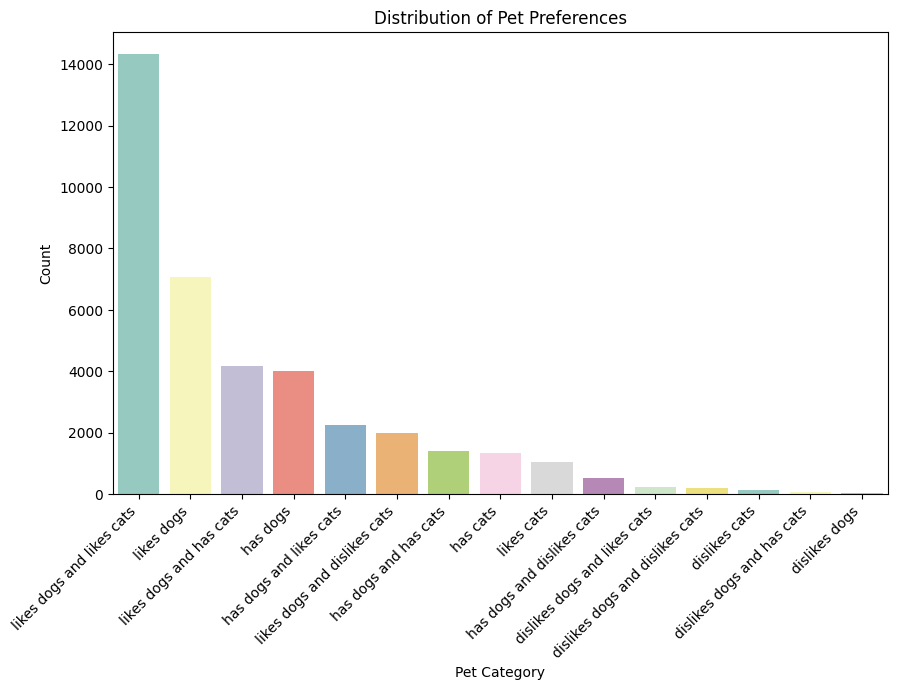

In [95]:

plt.figure(figsize=(10,6))
sns.countplot(x='pets', data=df, palette='Set3',
              order=df['pets'].value_counts().index)  # ensures sorted by frequency

plt.title('Distribution of Pet Preferences')
plt.xlabel('Pet Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()


##### - Include **pet preferences** as a compatibility filter to improve match quality.
##### - Recommend matches with similar pet interests, especially for users who strongly identify as pet lovers.
##### - Consider creating pet-related badges or interest tags to encourage engagement among users with shared preferences.

#### Recommendations

##### -Include **pet preferences** as a compatibility filter to improve match quality.
##### - Recommend matches with similar pet interests, especially for users who strongly identify as pet lovers.
##### - Consider creating pet-related badges or interest tags to encourage engagement among users with shared preferences.

In [96]:
pet_gender_age = pd.crosstab(
    [df['age_group'], df['gender']],
    df['pets'],
    normalize='index'
) * 100

print(pet_gender_age)


pets              dislikes cats  dislikes dogs  \
age_group gender                                 
18-25     f            0.270204       0.122820   
          m            0.193050       0.135135   
26-35     f            0.387597       0.167959   
          m            0.330852       0.073523   
36-45     f            0.376412       0.125471   
          m            0.243665       0.121832   
46+       f            0.235156       0.000000   
          m            0.267094       0.053419   

pets              dislikes dogs and dislikes cats  dislikes dogs and has cats  \
age_group gender                                                                
18-25     f                              0.614100                    0.196512   
          m                              0.444015                    0.308880   
26-35     f                              0.568475                    0.193798   
          m                              0.367613                    0.147045   
36-45     f  

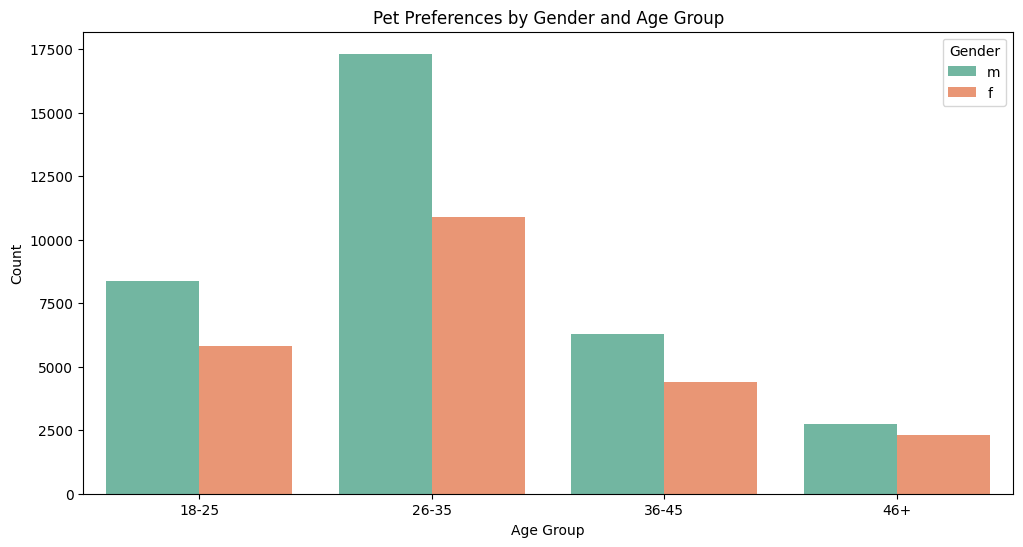

In [97]:

plt.figure(figsize=(12,6))
sns.countplot(x='age_group', hue='gender', data=df, palette='Set2')

plt.title('Pet Preferences by Gender and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()


##### - The **26–35** age group has the highest number of users for both males and females.
##### - Male users outnumber female users across all age groups.
##### - User counts decrease with increasing age, with the **46+** group having the fewest users.
##### - This chart represents the demographic distribution of users by age and gender rather than their pet preferences.

#### Recommendations

##### - Since this visualization does not include the **pets** variable, it cannot be used to analyze pet preferences across gender and age groups.
##### - To answer the question accurately, create a chart using **`pets` as the x-axis** and **`gender` or `age_group` as the hue**, or use a stacked bar chart or heatmap based on the `pet_gender_age` crosstab.

#### 4. Signs and Personality
##### Users’ self-reported zodiac signs (sign) can offer insights into personality preferences or trends. While not scientifically grounded, analyzing this data helps explore fun and engaging patterns.

#### Questions:
##### Create a pie chart showing the distribution of zodiac signs (sign) across the platform. Which signs are most and least represented? Is this the right chart? If not, replace with right chart.

##### How does sign vary across gender and status? Are there noticeable patterns or imbalances?

In [98]:
df['sign_first'] = df['sign'].str.split().str[0]


C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\869114508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sign_first'] = df['sign'].str.split().str[0]


In [99]:
df

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,...,speaks,last_online_date,last_online_time,age_group,income_category,height_cm,profile_completeness,city,state,sign_first
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,NaN,...,english,2012-06-28,20:30:00,18-25,NaN,190.50,91.0,south san francisco,california,gemini
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000.0,...,"english (fluently), spanish (poorly), french (...",2012-06-29,21:41:00,26-35,medium income,177.80,100.0,oakland,california,cancer
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,NaN,...,"english, french, c++",2012-06-27,09:10:00,36-45,NaN,172.72,77.0,san francisco,california,pisces
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000.0,...,"english, german (poorly)",2012-06-28,14:22:00,18-25,low income,180.34,95.0,berkeley,california,pisces
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,NaN,...,english,2012-06-27,21:26:00,26-35,NaN,167.64,82.0,san francisco,california,aquarius
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59941,59,single,f,NaN,NaN,socially,graduated from college/university,NaN,62.0,NaN,...,english,2012-06-12,21:47:00,46+,NaN,157.48,77.0,oakland,california,cancer
59942,24,single,m,fit,mostly anything,often,working on college/university,"white, other",72.0,NaN,...,english (fluently),2012-06-29,11:01:00,18-25,NaN,182.88,91.0,san francisco,california,leo
59943,42,single,m,average,mostly anything,not at all,graduated from masters program,asian,71.0,100000.0,...,english (fluently),2012-06-27,23:37:00,36-45,high income,180.34,95.0,south san francisco,california,sagittarius
59944,27,single,m,athletic,mostly anything,socially,working on college/university,"asian, black",73.0,NaN,...,"english (fluently), spanish (poorly), chinese ...",2012-06-23,13:01:00,26-35,NaN,185.42,91.0,san francisco,california,leo


##### A **pie chart is not the best choice** for this analysis because there are **12 zodiac signs** with very similar frequencies, making it difficult to compare categories accurately.

##### A **bar chart** is more appropriate as it allows easier comparison of the distribution across all zodiac signs.

C:\Users\Dell\AppData\Local\Temp\ipykernel_11736\874203918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sign_first', data=df, palette='Set3',


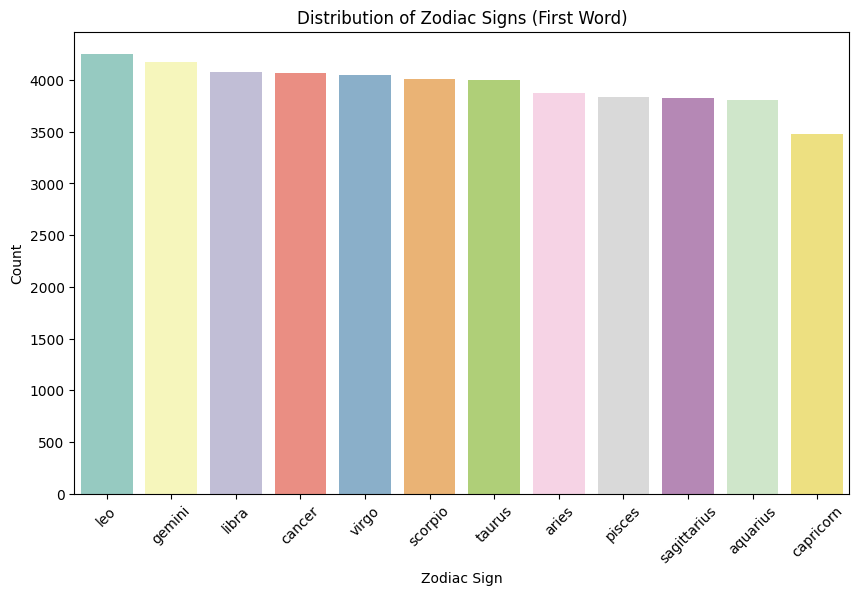

In [100]:

plt.figure(figsize=(10,6))
sns.countplot(x='sign_first', data=df, palette='Set3',
              order=df['sign_first'].value_counts().index)

plt.title('Distribution of Zodiac Signs (First Word)')
plt.xlabel('Zodiac Sign')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


##### - **Leo** is the most common zodiac sign among users, while **Capricorn** is the least common.
##### - The distribution of zodiac signs is fairly balanced, with only small differences in the number of users across signs.
##### - No zodiac sign dominates the platform, indicating a relatively even representation of users born throughout the year.

#### Recommendations

##### - Use a **bar chart** instead of a pie chart for comparing zodiac sign frequencies.
##### - Zodiac signs can be included as optional profile filters or conversation starters, but they should not be treated as significant predictors of user behavior or compatibility.

In [101]:
sign_gender_status = pd.crosstab(
    [df['gender'], df['status']],
    df['sign_first'],
    normalize='index'
) * 100

print(sign_gender_status)


sign_first              aquarius      aries     cancer  capricorn     gemini  \
gender status                                                                  
f      available        8.438061   7.719928   7.360862   5.565530   9.515260   
       married          3.508772  10.526316   9.649123   7.017544  14.035088   
       seeing someone   8.419839   6.805075   9.342561   7.727797   9.342561   
       single           8.081360   8.496911   8.420362   7.671278   8.557056   
       unknown          0.000000   0.000000   0.000000  25.000000   0.000000   
m      available        7.263158   8.315789   9.368421   7.789474   9.368421   
       married          8.270677   8.270677  11.278195   7.518797   7.518797   
       seeing someone   7.891637  10.482921   7.067138   7.184923   9.305065   
       single           8.016040   7.907031   8.693452   7.097251   8.876431   
       unknown         25.000000  25.000000   0.000000   0.000000   0.000000   

sign_first                   leo      l

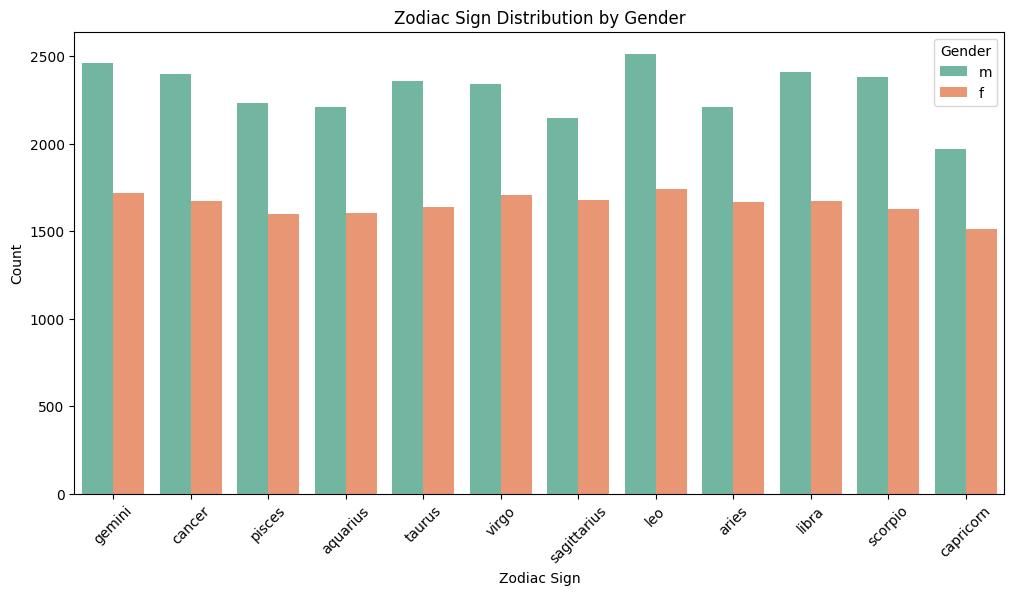

In [102]:

plt.figure(figsize=(12,6))
sns.countplot(x='sign_first', hue='gender', data=df, palette='Set2')

plt.title('Zodiac Sign Distribution by Gender')
plt.xlabel('Zodiac Sign')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.show()


##### - The distribution of zodiac signs is **fairly balanced** across both genders, with no major imbalances.
##### - Male users outnumber female users for every zodiac sign, reflecting the overall **60:40 gender distribution** of the platform.
##### - **Leo** has the highest number of users for both males and females, while **Capricorn** has the fewest.
##### - Overall, zodiac sign does not appear to vary significantly by gender, suggesting that signs are evenly represented across the user base.

#### Recommendations

##### - Since zodiac signs are evenly distributed across genders, they should be treated as an optional preference rather than a key matching criterion.
##### - Use zodiac signs as a fun engagement feature, such as profile badges or conversation starters, instead of relying on them for compatibility predictions.

In [103]:
sign_status = pd.crosstab(df['status'], df['sign_first'], normalize='index') * 100
print(sign_status)


sign_first       aquarius      aries     cancer  capricorn     gemini  \
status                                                                  
available        7.697412   8.095554   8.626410   6.967485   9.422694   
married          6.072874   9.311741  10.526316   7.287449  10.526316   
seeing someone   8.158508   8.624709   8.216783   7.459207   9.324009   
single           8.043206   8.152359   8.579875   7.335986   8.743604   
unknown         12.500000  12.500000   0.000000  12.500000   0.000000   

sign_first            leo     libra     pisces  sagittarius    scorpio  \
status                                                                   
available        8.958195  8.029197   8.294625     8.560053   8.891838   
married          6.882591  8.906883   7.287449     7.692308   5.668016   
seeing someone   9.090909  7.808858   7.459207     8.333333   8.100233   
single           8.966458  8.648096   8.095509     8.034110   8.466174   
unknown         37.500000  0.000000  12.5000

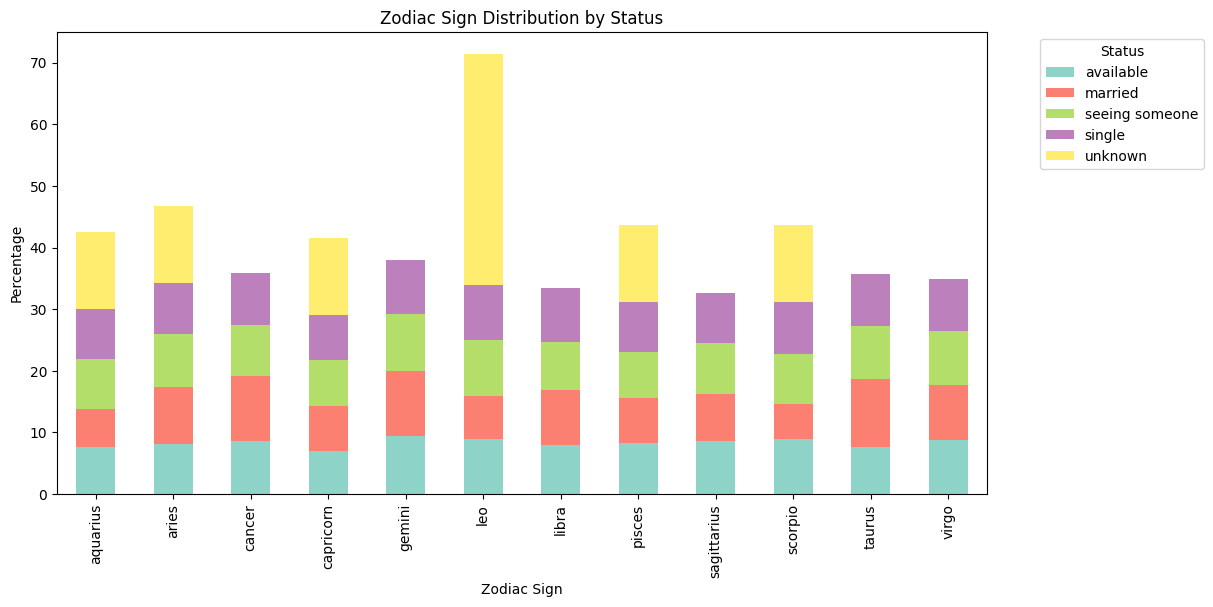

In [104]:
import matplotlib.pyplot as plt

sign_status.T.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set3')

plt.title('Zodiac Sign Distribution by Status')
plt.xlabel('Zodiac Sign')
plt.ylabel('Percentage')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


##### - The **single** category has the highest proportion across nearly all zodiac signs, indicating that most users are single regardless of their zodiac sign.
##### - The proportions of **available**, **married**, and **seeing someone** remain relatively consistent across all signs, with only minor variations.
##### - No zodiac sign shows a strong association with a particular relationship status, suggesting that relationship status is largely independent of zodiac sign.
##### - Overall, there are **no noticeable imbalances** in relationship status across different zodiac signs.

#### Recommendations

##### - Since zodiac signs show no meaningful variation across relationship statuses, they should not be used as a primary criterion for matchmaking.
##### - Instead, use zodiac signs as an optional profile feature or conversation starter to enhance user engagement and personalization.